# LOBSTER TimeGAN: Wiener noise amplitude ablation

Run top to bottom to compare the **same saved TimeGAN** at noise amplitudes
**1, 0.5, 0.25, and 0**, with three paired completions per amplitude.
Each case has its own full-day midpoint chart: training in blue, validation
in orange, and generated continuations in green.

This experiment changes noise **during inference**, keeping the learned weights
fixed to isolate noise sensitivity. Retraining separately would measure how
different noise distributions affect learning instead.

Amplitude multiplies the Wiener path's standard deviation; **variance scales
with amplitude squared**. The original notebook's per-event noise scaling is
retained, so amplitude 1 reproduces its sampling procedure. These continuations
extend far beyond the 64-event training windows and are exploratory simulations.
The validation prices are shown for comparison and never fed into generation.


In [1]:
from pathlib import Path
import sys

# Support launching from recognition/ or recognition/notebooks/.
project_dir = next(
    (directory for directory in (Path.cwd(), *Path.cwd().parents)
     if (directory / "dataset.py").exists()),
    None,
)
if project_dir is None:
    raise FileNotFoundError("Launch this notebook from the recognition project.")
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from dataset import LOBSTERLevel10Dataset, features_to_order_book
from predict import generate_wiener_paths, load_checkpoint


In [2]:
AMPLITUDES = [1.0, 0.5, 0.25, 0.0]
N_COMPLETIONS = 3
SEED = 0
CHECKPOINT_PATH = project_dir / "runs" / "timegan" / "model.pt"
DECODE_CHUNK_SIZE = 1024

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    # Small recurrent batches avoid the overhead of many CPU worker threads.
    torch.set_num_threads(1)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"No saved model at {CHECKPOINT_PATH}. "
        "Set CHECKPOINT_PATH to an existing run, or train once with "
        "'uv run python main.py'."
    )


In [3]:
model, checkpoint = load_checkpoint(CHECKPOINT_PATH, device=device)
model.eval()
sequence_length = checkpoint["training_config"]["sequence_length"]
train_data = LOBSTERLevel10Dataset(train=True)
test_data = LOBSTERLevel10Dataset(train=False)
feature_mean = checkpoint["feature_mean"].cpu().numpy()
feature_std = checkpoint["feature_std"].cpu().numpy()

# The real starting context and generated features must use the saved scale.
if (checkpoint["feature_names"] != list(train_data.FEATURE_NAMES)
        or not np.allclose(feature_mean, train_data.feature_mean)
        or not np.allclose(feature_std, train_data.feature_std)):
    raise ValueError("The checkpoint's features/normalization do not match this dataset.")

horizon = len(test_data)
boundary = len(train_data)
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Training window: {sequence_length} events; completion: {horizon:,} events")
print(f"Device: {device}; shared context and {N_COMPLETIONS} paired noise paths")


Checkpoint: /home/carson/.codex/worktrees/d599/PatternAnalysis-2026/recognition/runs/timegan/model.pt
Training window: 64 events; completion: 40,462 events
Device: cpu; shared context and 3 paired noise paths


## Paired noise paths

Draw the three base paths once, then multiply each by the requested amplitude.
All cases therefore share the same random innovations and final training context.
The Gaussian initializer returned by the noise helper is unused: these
continuations start from the real context's encoded latent.

As in the original completion notebook, each base increment has variance
$1/(T-1)$, where $T$ is the training window length. With amplitude $a$,
the input path at event $k$ has variance $a^2 k/(T-1)$ **per noise channel**.
This describes input noise, not generated price variance.


In [4]:
rng = torch.Generator(device=device).manual_seed(SEED)
base_paths, _ = generate_wiener_paths(
    N_COMPLETIONS, horizon + 1, model.generator.noise_dims,
    device=device, dtype=next(model.parameters()).dtype, rng=rng,
)
# Preserve the original completion notebook's training variance per event.
base_paths *= (horizon / (sequence_length - 1)) ** 0.5

variance_settings = pd.DataFrame({
    "amplitude": AMPLITUDES,
    "variance_multiplier": np.square(AMPLITUDES),
    "increment_variance": np.square(AMPLITUDES) / (sequence_length - 1),
    "endpoint_path_variance": np.square(AMPLITUDES) * horizon / (sequence_length - 1),
})
display(variance_settings.round(6))


,amplitude,variance_multiplier,increment_variance,endpoint_path_variance
0,1.00,1.0000,0.015873,642.253968
1,0.50,0.2500,0.003968,160.563492
2,0.25,0.0625,0.000992,40.140873
3,0.00,0.0000,0.000000,0.000000


In [5]:
@torch.inference_mode()
def complete_from_context(model, context, paths, amplitudes, chunk_size=1024):
    """Run all paired cases together, carrying each generated latent forward."""
    cases, samples = len(amplitudes), paths.shape[0]
    horizon = paths.shape[1] - 1
    initial = model.embedder(context)[:, -1]
    h = initial.repeat(cases * samples, 1)
    scales = paths.new_tensor(amplitudes)[:, None, None]
    features = torch.empty(
        cases * samples, horizon, model.model_config["feature_dims"],
        dtype=initial.dtype, device="cpu",
    )
    latent_chunk = initial.new_empty(
        cases * samples, min(chunk_size, horizon), initial.shape[-1],
    )

    for step in range(1, horizon + 1):
        noise = (scales * paths[None, :, step]).flatten(0, 1)
        h = model.generator.cell(noise, h)
        offset = (step - 1) % chunk_size
        latent_chunk[:, offset] = h
        if step % chunk_size == 0 or step == horizon:
            width = offset + 1
            # Chunk decoding bounds memory without resetting recurrent state.
            features[:, step - width:step] = model.decoder(
                latent_chunk[:, :width]
            ).cpu()

    return features.reshape(cases, samples, horizon, -1)


context = train_data.features[-sequence_length:].unsqueeze(0).to(device)
completed_features = complete_from_context(
    model, context, base_paths, AMPLITUDES, DECODE_CHUNK_SIZE,
)
print(f"Generated features (amplitude, completion, event, feature): {tuple(completed_features.shape)}")


Generated features (amplitude, completion, event, feature): (4, 3, 40462, 40)


In [6]:
def midpoint(book):
    return ((book["ASKp1"] + book["BIDp1"]) / 20_000).to_numpy()


training_midpoint = midpoint(train_data.books)
validation_midpoint = midpoint(test_data.books)
completion_midpoints = np.array([
    [
        midpoint(features_to_order_book(sequence, feature_mean, feature_std))
        for sequence in case
    ]
    for case in completed_features
])

# Every separate chart uses the same price scale for visual comparison.
price_min = min(training_midpoint.min(), validation_midpoint.min(), completion_midpoints.min())
price_max = max(training_midpoint.max(), validation_midpoint.max(), completion_midpoints.max())
margin = max(0.05 * (price_max - price_min), 0.01)
price_limits = (price_min - margin, price_max + margin)


def plot_completions(case_index):
    amplitude = AMPLITUDES[case_index]
    fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
    ax.plot(np.arange(boundary), training_midpoint,
            color="tab:blue", label="Training")
    ax.plot(np.arange(boundary, boundary + horizon), validation_midpoint,
            color="tab:orange", label="Validation")

    events = np.arange(boundary - 1, boundary + horizon)
    for index, prices in enumerate(completion_midpoints[case_index]):
        ax.plot(events, np.r_[training_midpoint[-1], prices],
                color="tab:green", alpha=0.5,
                label="Generated completions" if index == 0 else None)

    ax.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=1)
    ax.set(
        title=(f"AMZN midpoint completions: noise amplitude {amplitude:g} "
               f"(input variance ×{amplitude ** 2:g})"),
        xlabel="Event index", ylabel="Midpoint ($)", ylim=price_limits,
    )
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.legend()
    plt.show()


## Amplitude 1 — original noise variance


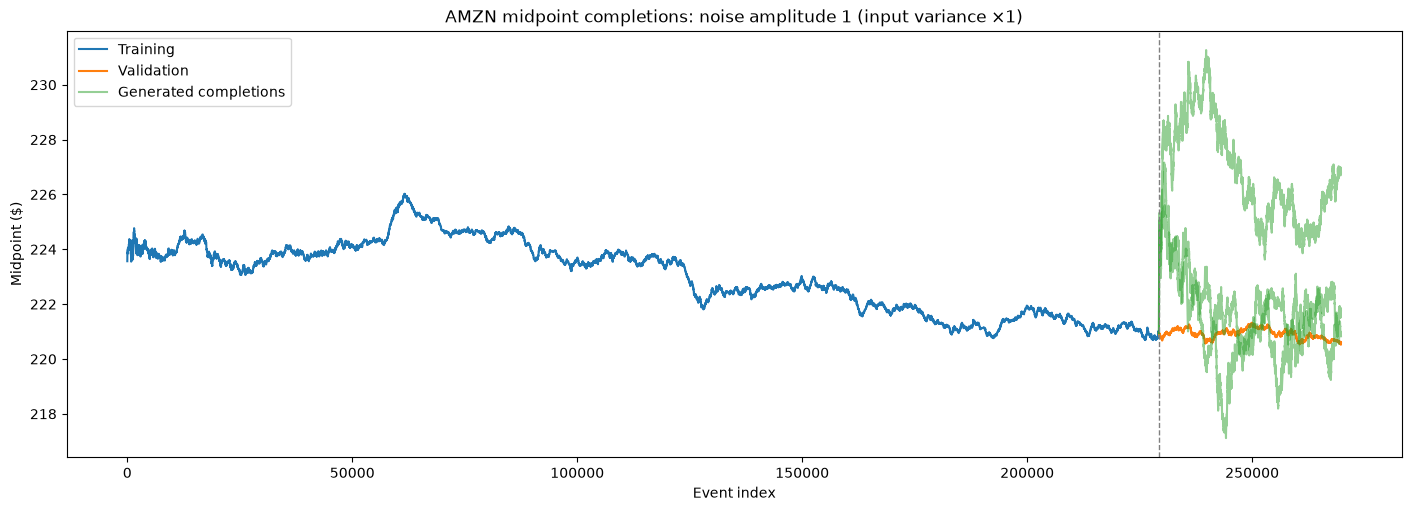

In [7]:
plot_completions(0)


## Amplitude 0.5 — 25% of original noise variance


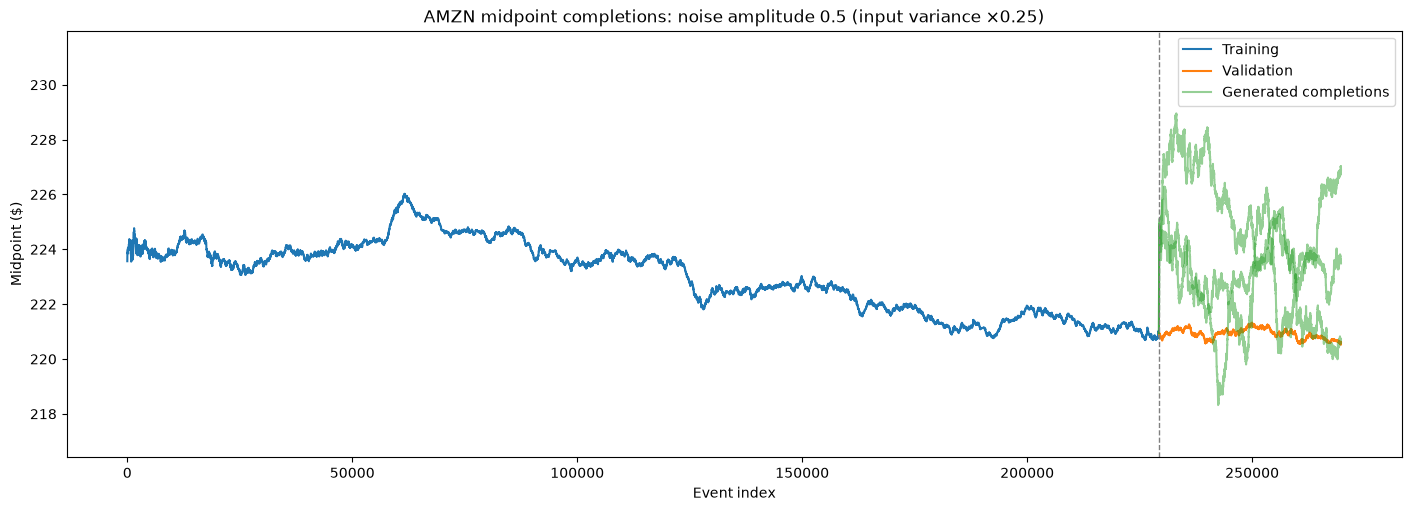

In [8]:
plot_completions(1)


## Amplitude 0.25 — 6.25% of original noise variance


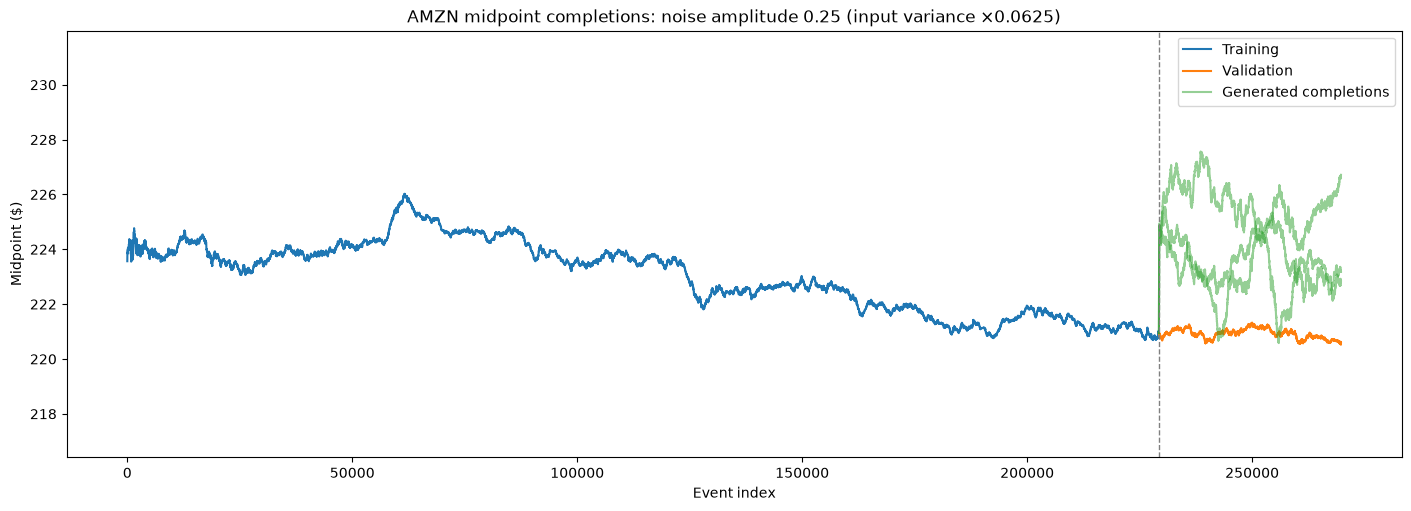

In [9]:
plot_completions(2)


## Amplitude 0 — deterministic continuation

The three completions coincide because they share the same starting context
and receive zero noise. Any remaining price movement comes from the learned
recurrent dynamics and decoding.


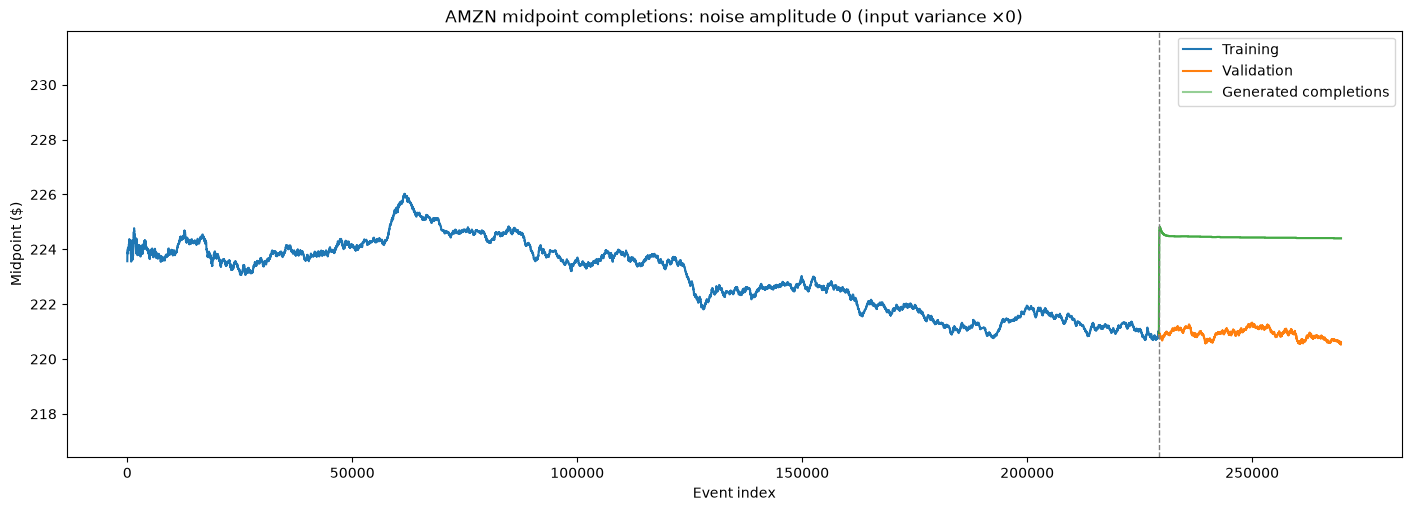

In [10]:
plot_completions(3)


## Drift and variability

The table separates event-to-event variation from the spread between completion
endpoints. Changes include the first transition from the last observed training
midpoint; differences never cross between independent completions.
A smaller endpoint spread does not establish realistic dynamics, and three
completions are a visual diagnostic rather than a reliable variance estimate.


In [11]:
summary_rows = []
for amplitude, prices in zip(AMPLITUDES, completion_midpoints):
    anchored = np.column_stack((np.full(N_COMPLETIONS, training_midpoint[-1]), prices))
    changes = np.diff(anchored, axis=1)
    summary_rows.append({
        "case": f"amplitude {amplitude:g}",
        "change_mean_dollars": changes.mean(),
        "change_std_dollars": changes.std(),
        "mean_endpoint_change_dollars": (prices[:, -1] - training_midpoint[-1]).mean(),
        "endpoint_std_dollars": prices[:, -1].std(),
    })

real_anchored = np.r_[training_midpoint[-1], validation_midpoint]
real_changes = np.diff(real_anchored)
summary_rows.append({
    "case": "real validation",
    "change_mean_dollars": real_changes.mean(),
    "change_std_dollars": real_changes.std(),
    "mean_endpoint_change_dollars": validation_midpoint[-1] - training_midpoint[-1],
    "endpoint_std_dollars": np.nan,
})
summary = pd.DataFrame(summary_rows).set_index("case")
display(summary.round(6))


,change_mean_dollars,change_std_dollars,mean_endpoint_change_dollars,endpoint_std_dollars
case,,,,
amplitude 1,0.000054,0.017329,2.195000,2.620709
amplitude 0.5,0.000068,0.010274,2.766667,2.531697
amplitude 0.25,0.000082,0.006451,3.300000,1.753073
amplitude 0,0.000085,0.002815,3.455000,0.000000
real validation,-0.000009,0.004953,-0.370000,NaN
